In [1]:
import json
import pandas as pd
import numpy as np

data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/preprocess/ALC_features_Functional.json'

In [4]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

In [5]:
df = pd.read_json(data_path, orient='index')
df.head()

,intoxicated,breath alcohol concentration,blood alcohol concentration,features
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses4038/5444038020_h_00.wav,na,0.0,0.0,{'F0semitoneFrom27.5Hz_sma3nz_amean': [27.5367...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses4038/5444038033_h_00.wav,na,0.0,0.0,{'F0semitoneFrom27.5Hz_sma3nz_amean': [25.3177...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses4038/5444038035_h_00.wav,na,0.0,0.0,{'F0semitoneFrom27.5Hz_sma3nz_amean': [25.8883...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses4038/5444038060_h_00.wav,na,0.0,0.0,{'F0semitoneFrom27.5Hz_sma3nz_amean': [25.5904...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses4038/5444038026_h_00.wav,na,0.0,0.0,{'F0semitoneFrom27.5Hz_sma3nz_amean': [25.3524...


In [6]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2)

In [7]:
print (f'Train contains {len(train)} examples.\nTest contains {len(test)} examples.')

Train contains 12144 examples.
Test contains 3036 examples.


In [8]:
train['features'][0]

{'F0semitoneFrom27.5Hz_sma3nz_amean': [29.03294563293457],
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm': [0.312167882919311],
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0': [19.35110092163086],
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0': [33.7763671875],
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0': [38.17869186401367],
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2': [18.827590942382812],
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope': [509.3846435546875],
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope': [624.6332397460938],
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope': [206.4912567138672],
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope': [279.3980407714844],
 'loudness_sma3_amean': [0.311811536550521],
 'loudness_sma3_stddevNorm': [1.1377729177474971],
 'loudness_sma3_percentile20.0': [0.07568851113319301],
 'loudness_sma3_percentile50.0': [0.11880433559417701],
 'loudness_sma3_percentile80.0': [0.5129985809326171],
 'loudness_sma3_pctlrange0-2': [0.43731006979942305],
 'loudness_

# Majority Baseline 
(Just one dummy feature)

In [9]:
# this keeps one first feature -- should not be informative enough for the model to work
def features_to_vec(feature_dict):
#     out_vector = []
#     for feature in feature_dict.values():
#         out_vector.append(feature)
    return [0]

In [10]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[5])} dimensions.")

The dataset has 12144 data samples.
Each data sample is a vector of 1 dimensions.


In [11]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = test['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in test['intoxicated']]

In [12]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [13]:
X_train[2:4]
#look at this; maybe we could collapse redundant features? like do PCA or any other dimensionality reduction

[[0], [0]]

In [14]:
y_train[:2]

[0, 0]

In [15]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [16]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)

BernoulliNB()

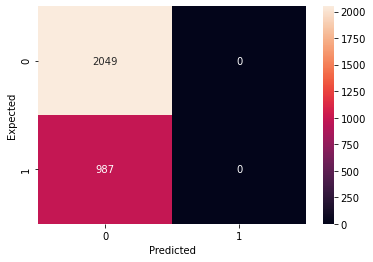

In [17]:
evaluate_classifier(nb_classifier, X_test, y_test)

# Actual Baseline

In [18]:
# this simply flattens all the features into one long concatenated vector
def features_to_vec(feature_dict):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

features_to_vec(train['features'][0])

[29.03294563293457,
 0.312167882919311,
 19.35110092163086,
 33.7763671875,
 38.17869186401367,
 18.827590942382812,
 509.3846435546875,
 624.6332397460938,
 206.4912567138672,
 279.3980407714844,
 0.311811536550521,
 1.1377729177474971,
 0.07568851113319301,
 0.11880433559417701,
 0.5129985809326171,
 0.43731006979942305,
 5.601758003234863,
 2.37084698677063,
 8.950011253356934,
 7.048959732055664,
 0.19156543910503301,
 1.446244001388549,
 25.370468139648438,
 0.43114855885505604,
 10.926197052001953,
 1.132243633270263,
 12.45566463470459,
 0.775822222232818,
 4.239081859588623,
 3.030457496643066,
 0.043229635804891,
 1.66524076461792,
 1.141924619674682,
 0.917887389659881,
 3.621402263641357,
 2.333773851394653,
 10.015212059020996,
 1.795267462730407,
 27.912830352783203,
 0.265397489070892,
 663.2835083007812,
 0.31351238489151,
 1446.6708984375,
 0.19631740450859,
 -115.33621978759766,
 -0.7395082712173461,
 1684.9742431640625,
 0.143926128745079,
 1185.1058349609375,
 0.4343

In [19]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[7])} dimensions.")

The dataset has 12144 data samples.
Each data sample is a vector of 88 dimensions.


In [20]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = test['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in test['intoxicated']]

In [21]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [22]:
#([set([type(x) for x in y]) for y in X_train])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [23]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)

BernoulliNB()

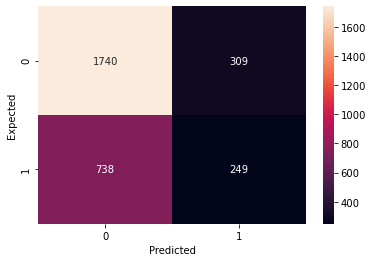

In [24]:
evaluate_classifier(nb_classifier, X_test, y_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [26]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
accuracy = knn_classifier.score(X_test, y_test)
accuracy

0.6198945981554678

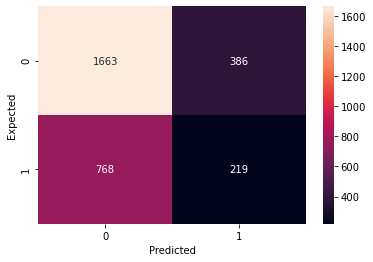

In [27]:
evaluate_classifier(knn_classifier, X_test, y_test)

In [28]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
accuracy = rf_classifier.score(X_test, y_test)
accuracy 

0.7355072463768116

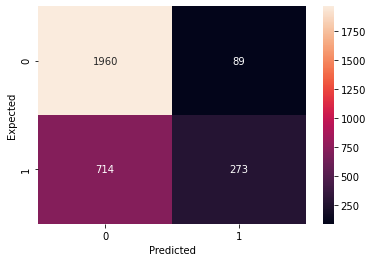

In [29]:
evaluate_classifier(rf_classifier, X_test, y_test)

In [30]:
svm_classifier = svm.LinearSVC()
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

/usr/lib64/python3.10/site-packages/sklearn/svm/_base.py:1199: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.6781949934123848

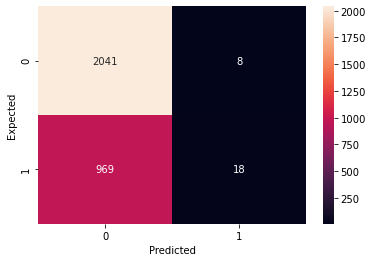

In [31]:
evaluate_classifier(svm_classifier, X_test, y_test)

# Majority Baseline for the Levels (Regression Task)

In [32]:
from sklearn import linear_model

In [33]:
linmodel = linear_model.LinearRegression(fit_intercept=True)

In [34]:
def features_to_vec(feature_dict, i=0):
    out_vector = [list(feature_dict.values())[i][0]] #first of i-th feature only
    return out_vector

X_train = train['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)

LinearRegression()

In [35]:
(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print(slope, intercept)

-0.00014288443948653605 0.0003103102283191316


In [36]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 0.00
Coefficient of determination: 0.00


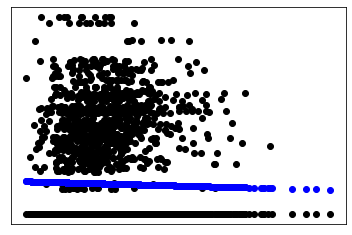

In [37]:
import matplotlib.pyplot as plt
# Plot outputs
#based on the one dimension of features
x_test_0 = [x[0] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [38]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = test['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur

24 0.025773629941934106
Mean squared error: 0.00
Coefficient of determination: 0.03


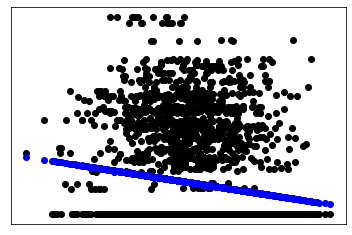

In [39]:
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

## On only those who have non-0 alc level
### In the breath
Feature 38 seems to be correlated with the alcohol level in blood

In [40]:
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)

54 0.030895494185956607
Mean squared error: 0.00
Coefficient of determination: 0.03


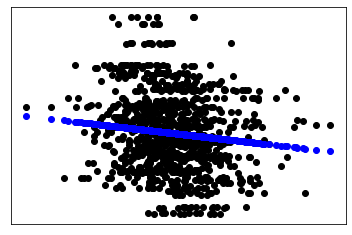

In [41]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = test['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### In the blood
Also feature 38, but less correlated

54 0.03340921880200809
Mean squared error: 0.00
Coefficient of determination: 0.03


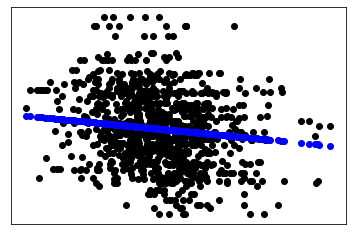

In [42]:
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['blood alcohol concentration']
    y_test = test['blood alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['blood alcohol concentration']
y_test = test['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

In [43]:
#What is this feature 38?
list(df['features'][0].keys())[38]

'logRelF0-H1-A3_sma3nz_amean'

## Multiple Linear Regression

### On all features and all data

In [44]:
X_train = train['features'].apply(features_to_vec).tolist() 
X_test = test['features'].apply(features_to_vec).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)

LinearRegression()

In [45]:
(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print(slope, intercept)

-2.806961351491669e-06 0.00096762515519562


In [46]:
from sklearn.metrics import mean_squared_error, r2_score

In [47]:
y_pred = linmodel.predict(X_test)

In [48]:
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 0.00
Coefficient of determination: 0.00


In [49]:
import matplotlib.pyplot as plt

Note: Visualization problematic. Only one feature (dimension) can be selected for 0x while we have many (88)

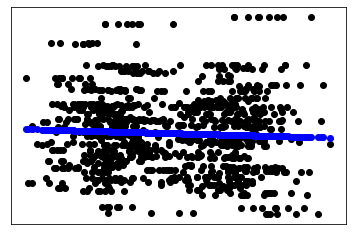

In [50]:
# Plot outputs
#based on the one dimension of features
x_test_0 = [x[0] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [51]:
# Plot outputs
#based on the first features
x_test_0 = [x[1] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

IndexError: list index out of range

### On only non-negative blood alcohol level on all features

In [ ]:
#NB: there's randomness here
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict, i=0):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -100
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['blood alcohol concentration']
    y_test = test['blood alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['blood alcohol concentration']
y_test = test['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative breath alcohol level on all features

In [ ]:
df = pd.read_json(data_path, orient='index')
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict, i=0):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -100
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = test['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative blood alcohol level on values of feature 38

In [ ]:
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict):
    out_vector = []
    feature = list(feature_dict.values())[38]
    for subfeature in feature:
        out_vector.append(subfeature)
    return out_vector


linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x)).tolist() 
y_train = train['blood alcohol concentration']
y_test = test['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative breath alcohol level on values of feature 38

In [ ]:
df = pd.read_json(data_path, orient='index')
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict):
    out_vector = []
    feature = list(feature_dict.values())[38]
    for subfeature in feature:
        out_vector.append(subfeature)
    return out_vector


linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()